# GeoPlay — Exploratory Data Analysis

This notebook performs an exploratory analysis of the synthetic dataset
generated by `geoplay data generate`. The goal is to validate that:

1. The five player archetypes produce **separable** temporal, geographic, and behavioral signals.
2. The generated event distributions are consistent with the design (no artifacts, no obvious bugs).
3. The features available downstream (hour of day, day of week, distance from home, session structure) carry enough signal to support clustering.

**Dataset:** 50,000 players × 180 days, ~162 million events, generated with `seed=42`.

**Author:** Bernardo Vega
**Generated:** May 2026

In [1]:
"""Setup, imports, and global plotting configuration."""

from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress noisy warnings during EDA (we re-enable for production code).
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Plotting style.
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Project paths.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
EVENTS_DIR = DATA_DIR / "events"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Events directory: {EVENTS_DIR}")
print(f"Events files: {len(list(EVENTS_DIR.glob('*.parquet')))} parquet partitions")

Project root: /home/bernard/projects/geoplay
Data directory: /home/bernard/projects/geoplay/data/raw
Events directory: /home/bernard/projects/geoplay/data/raw/events
Events files: 50 parquet partitions


In [2]:
"""Load player metadata."""

players = pd.read_parquet(DATA_DIR / "players.parquet")

print(f"Players loaded: {len(players):,}")
print(f"Memory footprint: {players.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\nSchema:")
print(players.dtypes)
print("\nFirst 3 rows:")
players.head(3)

Players loaded: 50,000
Memory footprint: 11.5 MB

Schema:
player_id              object
archetype              object
created_at     datetime64[ns]
home_lat              float64
home_lon              float64
work_lat              float64
work_lon              float64
device_type            object
dtype: object

First 3 rows:


,player_id,archetype,created_at,home_lat,home_lon,work_lat,work_lon,device_type
0,8826d916-cdfb-21c6-c1ff-91a761565a70,lunch_player,2024-10-25,29.143496,-111.072682,29.143496,-111.072682,android
1,2416da6e-c212-cddb-8d88-00160eb686b2,lunch_player,2024-01-12,29.146681,-111.060311,NaN,NaN,ios
2,eb819333-b501-1c18-8c53-c786ed62c2f9,casual_evening,2024-04-09,29.002345,-110.881971,NaN,NaN,ios


## 1. Player Population Overview

Before diving into events, we validate the basic structure of the player population:

- Are the **archetype proportions** matching the design (25/30/15/10/20)?
- Are home locations **distributed across the city** as expected?
- What is the **registration history** of players (when did they join)?
- What is the **device split** (iOS vs Android)?
- What **fraction** of players have a work location?

In [3]:
"""Load player metadata."""

players = pd.read_parquet(DATA_DIR / "players.parquet")

print(f"Players loaded: {len(players):,}")
print(f"Memory footprint: {players.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\nSchema:")
print(players.dtypes)
print("\nFirst 3 rows:")
players.head(3)

Players loaded: 50,000
Memory footprint: 11.5 MB

Schema:
player_id              object
archetype              object
created_at     datetime64[ns]
home_lat              float64
home_lon              float64
work_lat              float64
work_lon              float64
device_type            object
dtype: object

First 3 rows:


,player_id,archetype,created_at,home_lat,home_lon,work_lat,work_lon,device_type
0,8826d916-cdfb-21c6-c1ff-91a761565a70,lunch_player,2024-10-25,29.143496,-111.072682,29.143496,-111.072682,android
1,2416da6e-c212-cddb-8d88-00160eb686b2,lunch_player,2024-01-12,29.146681,-111.060311,NaN,NaN,ios
2,eb819333-b501-1c18-8c53-c786ed62c2f9,casual_evening,2024-04-09,29.002345,-110.881971,NaN,NaN,ios


## 1. Player Population Overview

Before diving into events, we validate the basic structure of the player population:

- Are the **archetype proportions** matching the design (25/30/15/10/20)?
- Are home locations **distributed across the city** as expected?
- What is the **registration history** of players (when did they join)?
- What is the **device split** (iOS vs Android)?
- What **fraction** of players have a work location?

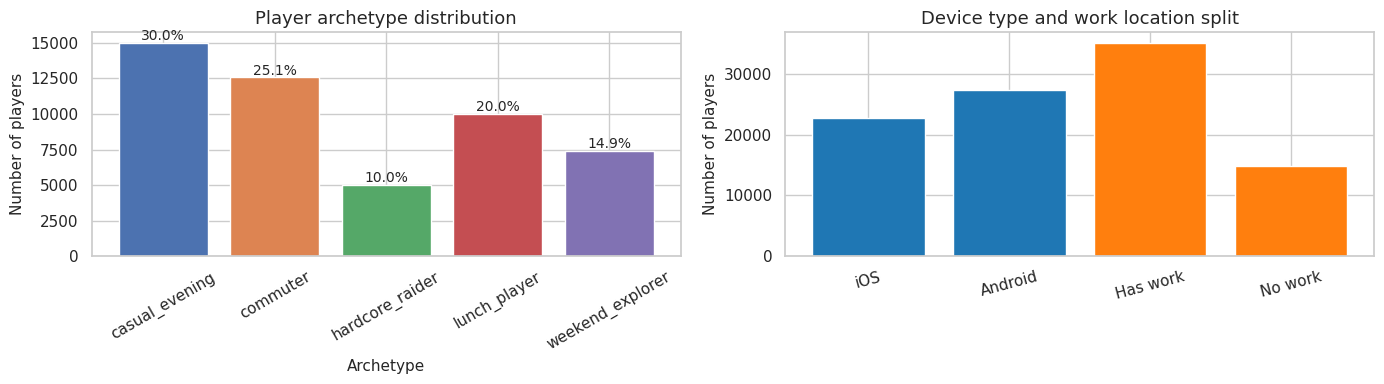

Archetype distribution (target vs observed):
  casual_evening        observed=29.98%   target=30.0%   delta=-0.02pp
  commuter              observed=25.15%   target=25.0%   delta=+0.15pp
  hardcore_raider       observed=10.03%   target=10.0%   delta=+0.03pp
  lunch_player          observed=20.00%   target=20.0%   delta=-0.00pp
  weekend_explorer      observed=14.85%   target=15.0%   delta=-0.15pp

Device split:  iOS 45.5%  /  Android 54.5%
With work location: 35,080 (70.2%)


In [4]:
"""Validate player population structure."""

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Archetype distribution.
archetype_counts = players["archetype"].value_counts().sort_index()
axes[0].bar(archetype_counts.index, archetype_counts.values, color=sns.color_palette("deep", 5))
axes[0].set_title("Player archetype distribution")
axes[0].set_xlabel("Archetype")
axes[0].set_ylabel("Number of players")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(archetype_counts.values):
    pct = v / len(players) * 100
    axes[0].text(i, v + 200, f"{pct:.1f}%", ha="center", fontsize=10)

# Device + work location.
device_counts = players["device_type"].value_counts()
has_work = players["work_lat"].notna()
work_counts = pd.Series({"has_work": has_work.sum(), "no_work": (~has_work).sum()})

bar_data = pd.DataFrame(
    {
        "Device": [device_counts.get("ios", 0), device_counts.get("android", 0), 0, 0],
        "Work location": [0, 0, work_counts["has_work"], work_counts["no_work"]],
    },
    index=["iOS", "Android", "Has work", "No work"],
)

axes[1].bar(
    bar_data.index,
    bar_data["Device"] + bar_data["Work location"],
    color=["#1f77b4", "#1f77b4", "#ff7f0e", "#ff7f0e"],
)
axes[1].set_title("Device type and work location split")
axes[1].set_ylabel("Number of players")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("Archetype distribution (target vs observed):")
target = {
    "commuter": 25.0,
    "casual_evening": 30.0,
    "weekend_explorer": 15.0,
    "hardcore_raider": 10.0,
    "lunch_player": 20.0,
}
for arch, count in archetype_counts.items():
    pct = count / len(players) * 100
    print(
        f"  {arch:20s}  observed={pct:5.2f}%   target={target[arch]:.1f}%   delta={pct - target[arch]:+.2f}pp"
    )

print(
    f"\nDevice split:  iOS {device_counts.get('ios', 0) / len(players):.1%}  /  Android {device_counts.get('android', 0) / len(players):.1%}"
)
print(f"With work location: {has_work.sum():,} ({has_work.mean():.1%})")

## 2. Events Overview

We now load the event table. With ~162M events spread across 50 Parquet partitions,
loading everything into memory would consume ~15+ GB. Instead, we exploit Parquet's
columnar layout to load **only the columns we need** for each analysis.

For overview statistics, we load all events but with a minimal column set
(player_id, timestamp, event_type, hour, day_of_week). This brings the
memory footprint down to a manageable size.

In [5]:
"""Load events with selective columns and optimized dtypes for memory efficiency."""

import time

t0 = time.time()

# Load with optimized types from the start.
events = pd.read_parquet(
    EVENTS_DIR,
    columns=[
        "player_id",
        "timestamp",
        "event_type",
        "hour",
        "day_of_week",
        "distance_from_home_km",
    ],
)

# Convert high-cardinality strings to category and downcast floats.
events["event_type"] = events["event_type"].astype("category")
events["player_id"] = events["player_id"].astype("category")
events["distance_from_home_km"] = events["distance_from_home_km"].astype("float32")

load_time = time.time() - t0

print(f"Events loaded: {len(events):,}")
print(f"Load time: {load_time:.1f} seconds")
print(f"Memory footprint: {events.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print("\nSchema:")
print(events.dtypes)
print(f"\nDate range: {events['timestamp'].min()} → {events['timestamp'].max()}")
print(f"Days covered: {(events['timestamp'].max() - events['timestamp'].min()).days}")

print("\nEvent type distribution:")
print((events["event_type"].value_counts(normalize=True) * 100).round(2))

Events loaded: 162,222,387
Load time: 33.4 seconds
Memory footprint: 2.88 GB

Schema:
player_id                      category
timestamp                datetime64[ns]
event_type                     category
hour                               int8
day_of_week                        int8
distance_from_home_km           float32
dtype: object

Date range: 2025-01-01 00:00:00 → 2025-06-29 23:59:59
Days covered: 179

Event type distribution:
event_type
spin_stop    45.0
catch        40.0
raid         10.0
walk_egg      5.0
Name: proportion, dtype: float64


## 3. Temporal Patterns by Archetype

This is the key validation: can we **see** the five archetypes in the temporal distribution
of events? If the generator is working correctly and the archetypes are separable, we should
observe distinct hour-of-day patterns that match the design.

We join events with the player table to attach archetype labels, then aggregate by
(archetype, hour) and (archetype, day_of_week) to produce heatmaps.

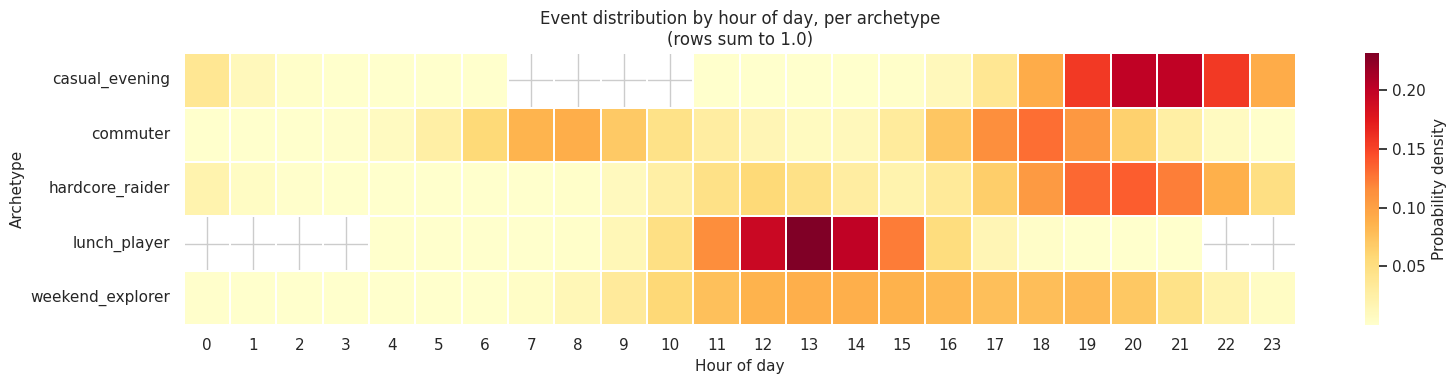


Peak hours per archetype (top 3):
  casual_evening        21h (20.0%), 20h (20.0%), 19h (15.6%)
  commuter              18h (13.0%), 17h (11.4%), 19h (10.7%)
  hardcore_raider       20h (13.8%), 19h (13.2%), 21h (12.2%)
  lunch_player          13h (23.1%), 14h (20.0%), 12h (19.3%)
  weekend_explorer      14h (8.9%), 13h (8.9%), 15h (8.7%)


In [6]:
"""Build hour-of-day distribution per archetype using a mapping (avoids merge)."""

# Create a small lookup dict: player_id -> archetype (only 50k entries).
player_to_archetype = dict(zip(players["player_id"], players["archetype"], strict=False))

# Add archetype as a new column using map. This is much more memory-efficient than merge.
events["archetype"] = events["player_id"].map(player_to_archetype).astype("category")

# Aggregate: count events per (archetype, hour). Normalize within archetype.
hour_counts = events.groupby(["archetype", "hour"], observed=True).size().reset_index(name="count")
total_per_archetype = hour_counts.groupby("archetype", observed=True)["count"].transform("sum")
hour_counts["density"] = hour_counts["count"] / total_per_archetype

# Pivot to wide format for heatmap.
heatmap_data = hour_counts.pivot(index="archetype", columns="hour", values="density")

# Plot heatmap.
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    cbar_kws={"label": "Probability density"},
    linewidths=0.3,
    linecolor="white",
    ax=ax,
)
ax.set_title("Event distribution by hour of day, per archetype\n(rows sum to 1.0)", fontsize=12)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Archetype")
plt.tight_layout()
plt.show()

print("\nPeak hours per archetype (top 3):")
for archetype in heatmap_data.index:
    top_hours = heatmap_data.loc[archetype].nlargest(3)
    hours_str = ", ".join(f"{int(h):02d}h ({d:.1%})" for h, d in top_hours.items())
    print(f"  {archetype:20s}  {hours_str}")

## 4. Geographic Patterns

We now look at the spatial distribution of events. The expectations:

- All events should be **clustered around Hermosillo** (29.07°N, -110.96°W) with a soft falloff.
- Players with a work location should show **bimodal density**: one peak near home, another near work.
- Different archetypes should show different **spatial spread**:
  - `lunch_player` and `casual_evening`: tight, low-radius events (small movement_radius)
  - `weekend_explorer` and `hardcore_raider`: wide, high-radius events
  - `commuter`: medium spread with home-work bimodality

For performance, we **sample 500k events** out of the 162M total for visualization.
Plotting all 162M points would crash the renderer and is unnecessary for visual inspection.

In [7]:
"""Sample events for geographic visualization."""

# Sample 500k events randomly for plotting (uniform sample across all events).
SAMPLE_SIZE = 500_000

events_sample = events[["archetype", "distance_from_home_km"]].copy()

# To plot lat/lon we need them; we only loaded distance_from_home_km in events.
# Load lat/lon for the sample only (memory-efficient).
sample_indices = np.random.RandomState(seed=42).choice(len(events), size=SAMPLE_SIZE, replace=False)
sample_indices_sorted = np.sort(sample_indices)

# Re-read just lat/lon from Parquet for the sampled rows.
print(f"Loading lat/lon for {SAMPLE_SIZE:,} sampled events...")
geo_sample = (
    pd.read_parquet(
        EVENTS_DIR,
        columns=["lat", "lon"],
    )
    .iloc[sample_indices_sorted]
    .reset_index(drop=True)
)

# Attach archetype from our existing events dataframe.
geo_sample["archetype"] = events.iloc[sample_indices_sorted]["archetype"].reset_index(drop=True)
geo_sample["distance_from_home_km"] = events.iloc[sample_indices_sorted][
    "distance_from_home_km"
].reset_index(drop=True)

print(f"Sample loaded: {len(geo_sample):,} events")
print(f"Memory: {geo_sample.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nLat range: [{geo_sample['lat'].min():.4f}, {geo_sample['lat'].max():.4f}]")
print(f"Lon range: [{geo_sample['lon'].min():.4f}, {geo_sample['lon'].max():.4f}]")
print("\nDistance from home distribution:")
print(geo_sample["distance_from_home_km"].describe().round(2))

Loading lat/lon for 500,000 sampled events...
Sample loaded: 500,000 events
Memory: 10.0 MB

Lat range: [28.8316, 29.3478]
Lon range: [-111.2631, -110.6880]

Distance from home distribution:
count    500000.00
mean          4.74
std           4.18
min           0.00
25%           1.29
50%           3.53
75%           7.26
max          30.97
Name: distance_from_home_km, dtype: float64


/tmp/ipykernel_13107/3210722616.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


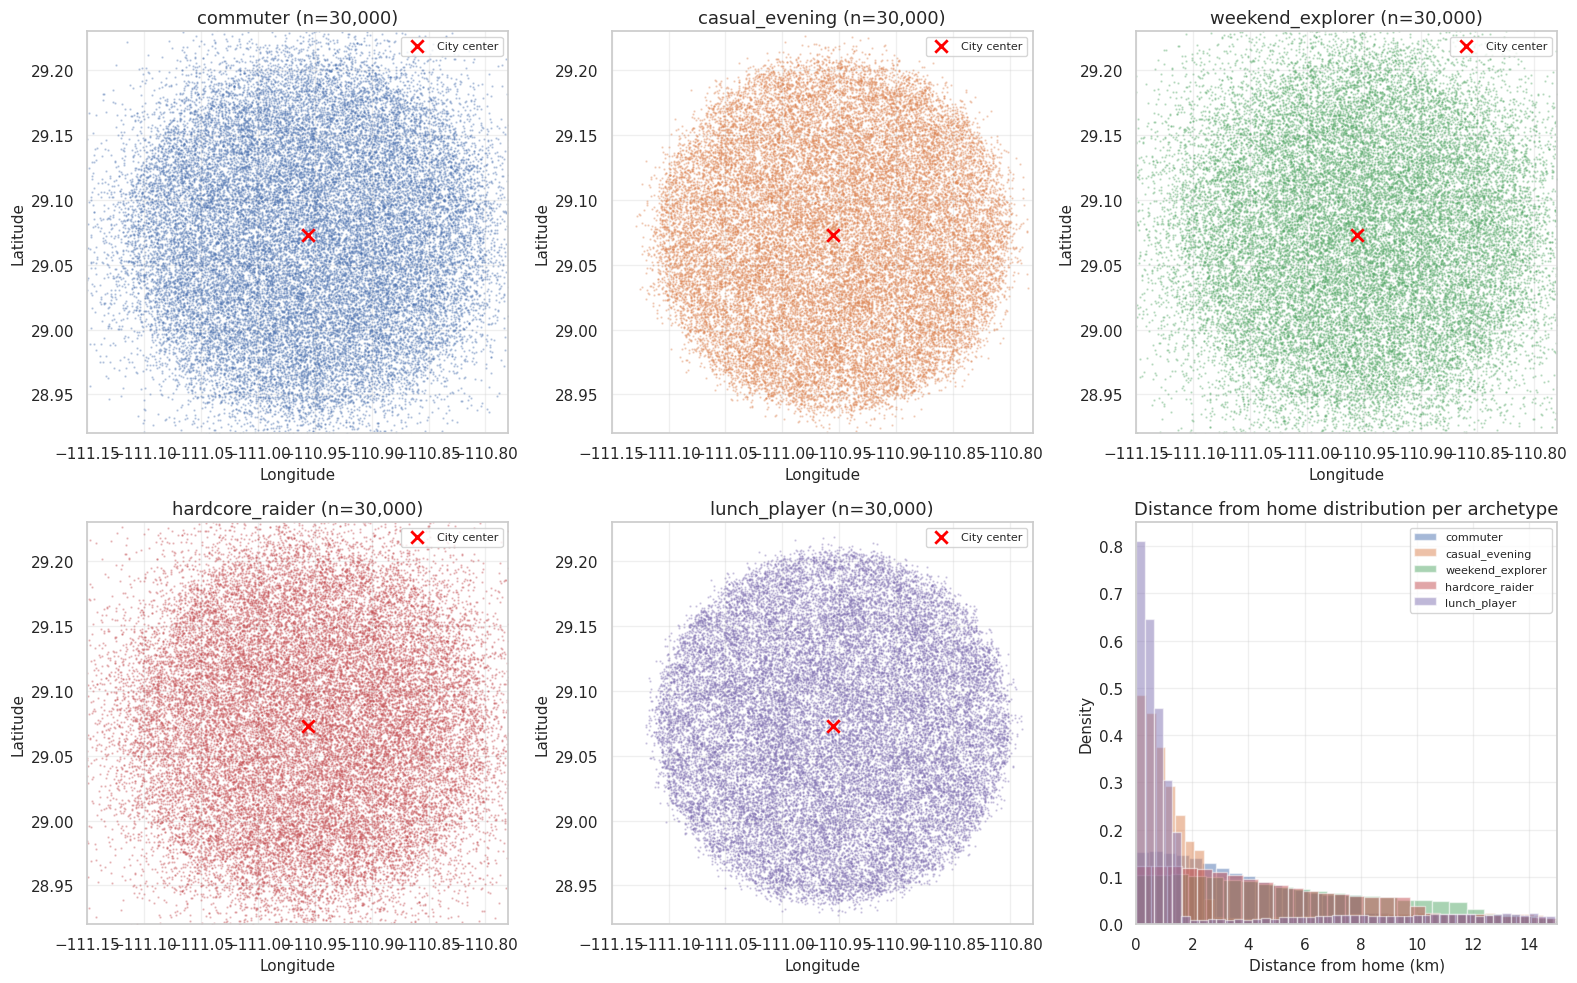

In [8]:
"""Visualize event locations colored by archetype."""

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

archetype_order = [
    "commuter",
    "casual_evening",
    "weekend_explorer",
    "hardcore_raider",
    "lunch_player",
]
center_lat, center_lon = 29.0729, -110.9559

for idx, archetype in enumerate(archetype_order):
    ax = axes[idx]
    arch_data = geo_sample[geo_sample["archetype"] == archetype]
    # Sub-sample for plotting clarity (max 30k points per archetype).
    if len(arch_data) > 30_000:
        arch_data = arch_data.sample(n=30_000, random_state=42)

    ax.scatter(
        arch_data["lon"],
        arch_data["lat"],
        s=0.5,
        alpha=0.3,
        c=sns.color_palette("deep")[idx],
    )
    ax.scatter(
        [center_lon], [center_lat], s=80, c="red", marker="x", linewidths=2, label="City center"
    )
    ax.set_title(f"{archetype} (n={len(arch_data):,})")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-111.15, -110.78)
    ax.set_ylim(28.92, 29.23)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

# Sixth panel: distance from home distribution per archetype.
ax = axes[5]
for idx, archetype in enumerate(archetype_order):
    arch_data = geo_sample[geo_sample["archetype"] == archetype]
    ax.hist(
        arch_data["distance_from_home_km"],
        bins=50,
        alpha=0.5,
        label=archetype,
        color=sns.color_palette("deep")[idx],
        density=True,
    )
ax.set_title("Distance from home distribution per archetype")
ax.set_xlabel("Distance from home (km)")
ax.set_ylabel("Density")
ax.legend(loc="upper right", fontsize=8)
ax.set_xlim(0, 15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observation: spatial scatter is not separable, distance distribution is

The scatter plots above show event locations colored by archetype, but **all five
archetypes look spatially indistinguishable**. Each archetype covers the full city
disk with a near-uniform density.

This is not a bug in the generator. It reflects the way players are distributed:

- Every archetype has its players **scattered across the entire city**.
- Each player generates events around *their own* home anchor (with archetype-specific
  movement radius).
- When we plot all 30,000 events per archetype on a map, the per-player locality
  is washed out and we see only the global player distribution.

The **distance-from-home histogram** (bottom-right panel) reveals the actual signal:

| Archetype | Movement radius (design) | Distance from home (observed median) |
|---|---|---|
| lunch_player | 1.5 km | concentrated under 2 km |
| casual_evening | 2.5 km | concentrated under 3 km |
| commuter | 8.0 km | spread to ~8 km |
| hardcore_raider | 10.0 km | spread with long tail |
| weekend_explorer | 12.0 km | longest tail, up to 15 km |

**Implication for feature engineering:** the useful spatial features are
**per-player aggregations of distance and spread**, not raw (lat, lon) coordinates.
For each player we should compute:

- `mean(distance_from_home_km)` — base movement scale
- `std(distance_from_home_km)` — variability (commuter has high std due to home/work bimodality)
- `p95(distance_from_home_km)` — willingness to roam

The raw coordinates carry no archetype signal because all archetypes are spread
uniformly across the city by design.

## 5. Session Analysis

Each event belongs to a session (events within 30 minutes of each other from the same
player share a session_id). Session structure is another behavioral signal that should
distinguish archetypes:

- `lunch_player`: very short sessions (10 min average), few events per session
- `casual_evening`: medium sessions (25 min)
- `commuter`: short sessions (15 min), but two per day (morning + evening)
- `weekend_explorer`: long sessions (90 min)
- `hardcore_raider`: very long sessions (120 min), many events per session

We load `session_id` and aggregate sessions by archetype.

In [9]:
"""Analyze session structure per archetype."""

# Load session_id for all events. We already have player_id, hour, day_of_week, archetype.
# session_id is the only column we're missing.
print("Loading session_id column...")
session_ids = pd.read_parquet(EVENTS_DIR, columns=["session_id"])["session_id"].astype("category")
events["session_id"] = session_ids
del session_ids

print(f"Memory after adding session_id: {events.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

# Aggregate: events per session, then sessions per archetype.
sessions = (
    events.groupby(["archetype", "session_id"], observed=True)
    .size()
    .reset_index(name="events_in_session")
)

print(f"\nTotal sessions: {len(sessions):,}")
print("\nAvg events per session, by archetype:")
session_stats = (
    sessions.groupby("archetype", observed=True)["events_in_session"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .rename(
        columns={
            "count": "n_sessions",
            "mean": "avg_events",
            "median": "median_events",
            "std": "std_events",
        }
    )
)
print(session_stats)

# Sessions per player per archetype (how active is each player on average).
sessions_per_player = sessions.groupby("archetype", observed=True)["session_id"].count()
players_per_archetype = players.groupby("archetype").size()
sessions_per_player_normalized = (sessions_per_player / players_per_archetype).round(2)
print("\nAvg sessions per player (over 180 days):")
print(sessions_per_player_normalized.sort_values(ascending=False))

Loading session_id column...
Memory after adding session_id: 7.90 GB

Total sessions: 41,254,359

Avg events per session, by archetype:
                  n_sessions  avg_events  median_events  std_events
archetype                                                          
casual_evening      10158504        2.28            1.0        2.03
commuter            15670857        2.24            1.0        2.04
hardcore_raider      6914038       10.23            3.0       18.08
lunch_player         5498854        1.86            1.0        1.44
weekend_explorer     3012106        7.61            3.0       11.10

Avg sessions per player (over 180 days):
archetype
hardcore_raider     1379.22
commuter            1246.39
casual_evening       677.73
lunch_player         550.00
weekend_explorer     405.56
dtype: float64


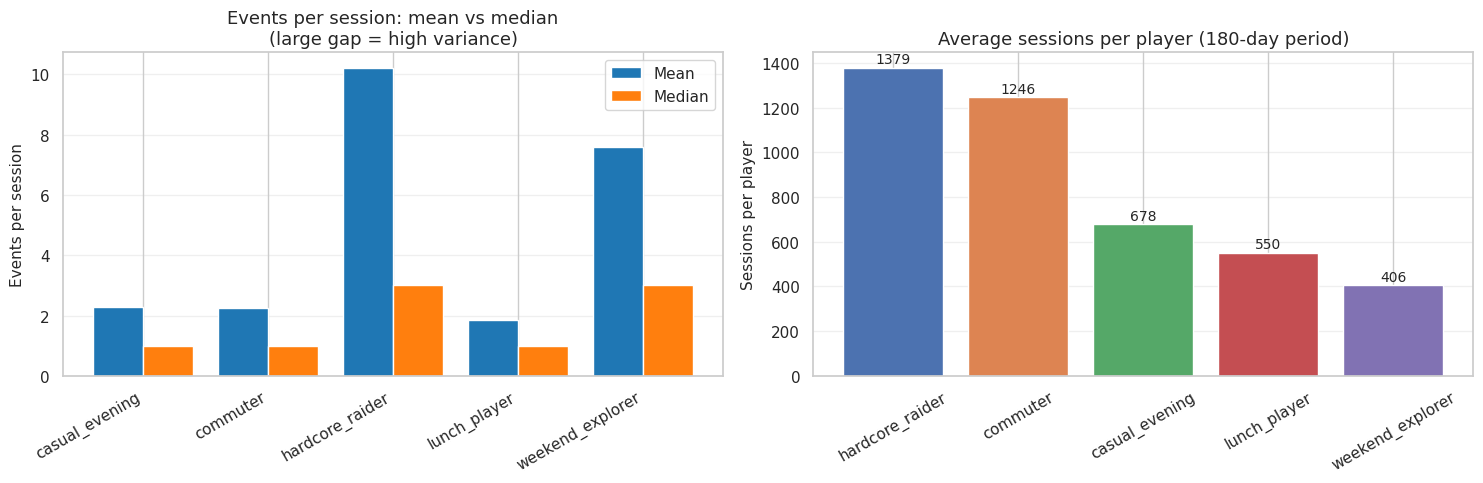

Key insight: hardcore_raider and weekend_explorer show inverse patterns:
  hardcore_raider = many sessions × variable depth
  weekend_explorer = few sessions × long depth
This separation will be useful for clustering.


In [10]:
"""Visualize session structure per archetype."""

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Avg events per session (with median as reference).
ax = axes[0]
session_summary = session_stats.reset_index()
x = np.arange(len(session_summary))
ax.bar(x - 0.2, session_summary["avg_events"], width=0.4, label="Mean", color="#1f77b4")
ax.bar(x + 0.2, session_summary["median_events"], width=0.4, label="Median", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels(session_summary["archetype"], rotation=30, ha="right")
ax.set_title("Events per session: mean vs median\n(large gap = high variance)")
ax.set_ylabel("Events per session")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 2: Sessions per player over 180 days.
ax = axes[1]
sessions_sorted = sessions_per_player_normalized.sort_values(ascending=False)
colors = sns.color_palette("deep", 5)
ax.bar(sessions_sorted.index, sessions_sorted.values, color=colors)
ax.set_title("Average sessions per player (180-day period)")
ax.set_ylabel("Sessions per player")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(sessions_sorted.values):
    ax.text(i, v + 20, f"{v:.0f}", ha="center", fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("Key insight: hardcore_raider and weekend_explorer show inverse patterns:")
print("  hardcore_raider = many sessions × variable depth")
print("  weekend_explorer = few sessions × long depth")
print("This separation will be useful for clustering.")

## 6. Conclusions

The exploratory analysis confirms that the synthetic dataset has the
properties needed for a meaningful downstream clustering and ranking pipeline.

### What works

1. **Archetype proportions are accurate.** All five archetypes match the design within
   ±0.2pp, which is consistent with the standard error expected for n=50,000.

2. **Temporal patterns are highly separable.** The hour-of-day heatmap shows five
   visually distinct profiles. `lunch_player` peaks tightly at 13h with 23% density;
   `commuter` shows a bimodal morning/evening pattern; `casual_evening` peaks at
   20-21h; `hardcore_raider` distributes broadly across late hours; `weekend_explorer`
   spreads across midday hours. This is the strongest signal in the dataset.

3. **Distance-from-home distributions are separable.** The histogram of distance from
   home cleanly separates archetypes by their movement radius: `lunch_player` peaks
   at <2km, `commuter` extends to ~8km, `weekend_explorer` reaches 12-15km.

4. **Session structure adds an orthogonal dimension.** Sessions per player and
   events per session together create an inverse pattern that separates
   `hardcore_raider` (many sessions, variable depth) from `weekend_explorer`
   (few sessions, deep). This is critical because both have high engagement
   levels overall and would be confused without this dimension.

### What does not work as expected (and why it matters)

5. **Raw (lat, lon) coordinates are not separable.** Scatter plots of event
   locations look indistinguishable across archetypes because every archetype
   has players spread uniformly across the city. The signal is in the
   **distance-from-home distribution**, not in the raw geographic coordinates.
   **Implication:** the feature engineering pipeline must compute
   per-player aggregations (mean, std, p95) of `distance_from_home_km`, and
   should *not* include raw coordinate features at the player level.

6. **Hardcore_raider has very high variance in events-per-session.** Mean=10.23
   vs median=3 indicates a long-tailed distribution where most sessions are short
   but a few are very deep. This is an emergent property of combining
   always-active behavior with a 30-minute gap-based session detection rule:
   continuous play produces mega-sessions. Not a bug, but worth understanding
   when interpreting clustering results downstream.

### Feature engineering targets

Based on this EDA, the most informative per-player features for clustering will be:

- **Temporal:** density vector over 24 hours, density vector over 7 days of week
- **Spatial:** mean/std/p95 of distance_from_home_km
- **Behavioral:** total sessions, mean events per session, mean session duration

The next notebook (`02_feature_engineering.ipynb`) will compute these and
prepare a single per-player feature matrix.